### Импорты
Подключает все необходимые библиотеки. `TensorDataset` и `DataLoader` добавлены для организации батчевого обучения — без них загрузка 1.5 млн строк одним куском приводила бы к переполнению памяти и нестабильному обучению.


In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

### 1. Загрузка и очистка данных
Загружает CSV и устраняет 12 строк-заголовков, встроенных в файл через каждые ~8 400 строк (артефакт записи данных). `errors="coerce"` превращает строку `"distance2"` в `NaN`, после чего `dropna()` удаляет такие строки.

In [ ]:
DATA_PATH = "/Users/anna/data_neuro/data3winds.csv" 

data = pd.read_csv(DATA_PATH)
data.columns = data.columns.str.strip()

for col in ["distance1", "distance2", "distance3", "intI", "intJ"]:
    data[col] = pd.to_numeric(data[col], errors="coerce")

data = data.dropna().reset_index(drop=True)

print("Данные загружены:", data.shape)
print(data.describe())


Данные загружены: (117600, 5)
           distance1      distance2      distance3           intI  \
count  117600.000000  117600.000000  117600.000000  117600.000000   
mean        5.661807       3.387141       5.666880       8.853117   
std         6.374695       4.524657       6.418244       1.358027   
min         0.001016       0.000230       0.000881       6.999750   
25%         0.593638       0.500223       0.493816       7.042537   
50%         3.110415       2.575220       3.037000       9.240060   
75%         9.051540       3.550050       9.182615      10.063300   
max        22.566300      22.496600      22.275500      11.018600   

                intJ  
count  117600.000000  
mean        6.002715  
std         1.072799  
min         4.668490  
25%         4.691327  
50%         6.263130  
75%         6.919120  
max         8.087190  


### 2. Физические функции
Реализует физическую модель. Потенциал состоит из трёх слагаемых с разными нелинейностями

In [ ]:
def pair_potential(r, intI, intJ, dkappa):
    r = np.maximum(r, 1e-8) 
    return intI * np.exp(-r) + intJ / r + dkappa * r**2


def total_energy(row, dkappa):
    r1 = row["distance1"]
    r2 = row["distance2"]
    r3 = row["distance3"]
    intI = row["intI"]
    intJ = row["intJ"]
    return (
        pair_potential(r1, intI, intJ, dkappa)
        + pair_potential(r2, intI, intJ, dkappa)
        + pair_potential(r3, intI, intJ, dkappa)
    )


### 3. Построение расширенного датасета
Каждая из 117 600 строк дублируется 13 раз — для каждого значения dkappa вычисляется отдельное значение энергии. dkappa добавляется как 6-й входной признак. В итоге получается полный обучающий датасет.

In [ ]:
dk_values = np.arange(-0.3, 0.31, 0.05) 

rows = []
for _, row in data.iterrows():
    for dk in dk_values:
        E = total_energy(row, dk)
        rows.append([
            row["distance1"],
            row["distance2"],
            row["distance3"],
            row["intI"],
            row["intJ"],
            dk,
            E,
        ])

dataset = np.array(rows, dtype=np.float64)

X_raw = dataset[:, :6]  
y_raw = dataset[:, 6:7]  


Размер датасета X: (1528800, 6)   y: (1528800, 1)


### 4. Разведочный анализ данных (EDA)
Строит гистограммы распределений всех 6 признаков и целевой переменной. Важная ячейка: задокументировано, что распределение данных трёхвихревого датасета никто не смотрел, и неизвестно, удалось ли исправить перекос к минимуму энергии. EDA даёт первый визуальный ответ на этот вопрос.
**Что смотреть на графиках:**
- `distance1–3`: должны быть равномерно распределены или иметь умеренный пик — сильный пик в малых расстояниях указывает на сохранившийся перекос
- `intI`, `intJ`: непрерывные диапазоны ([7.0, 11.0] и [4.7, 8.1] соответственно)
- `dkappa`: должна быть равномерная гистограмма из 13 столбцов — подтверждает корректное расширение
- `Энергия E`: сильно правосторонняя (mean ≫ median) — следствие сингулярности `intJ/r` при малых r

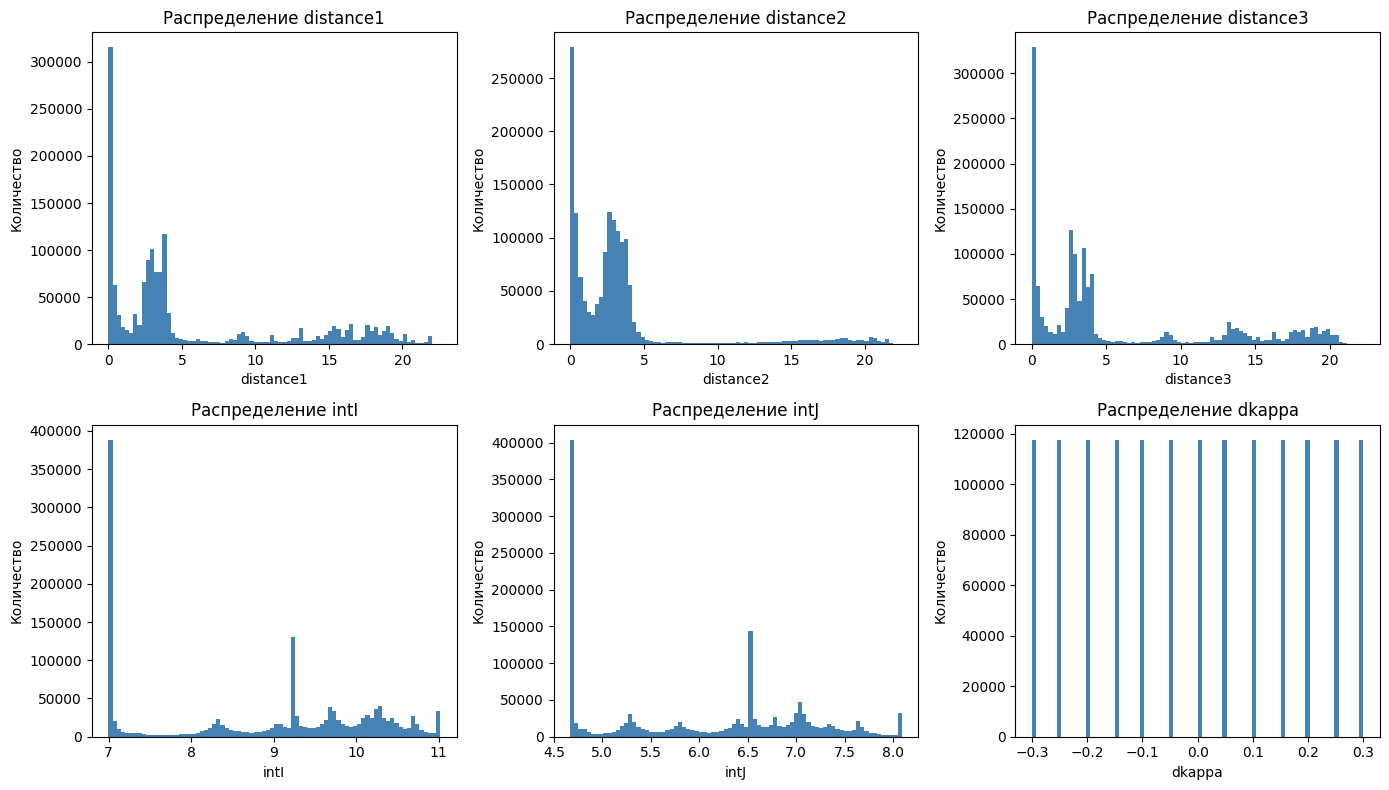

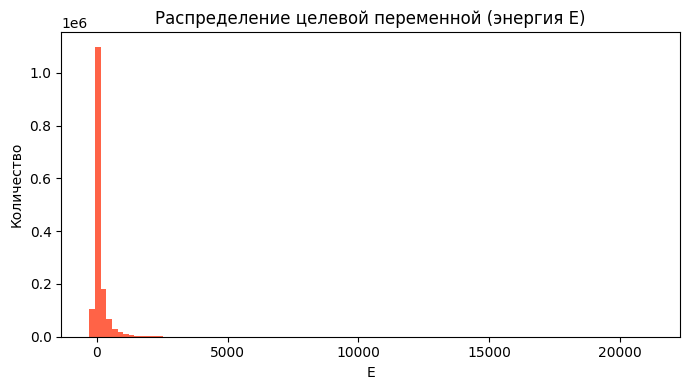

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
feature_names = ["distance1", "distance2", "distance3", "intI", "intJ", "dkappa"]
for i, (ax, name) in enumerate(zip(axes.flat, feature_names)):
    ax.hist(X_raw[:, i], bins=80, color='steelblue', edgecolor='none')
    ax.set_title(f'Распределение {name}')
    ax.set_xlabel(name)
    ax.set_ylabel('Количество')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(y_raw[:, 0], bins=100, color='tomato', edgecolor='none')
plt.title('Распределение целевой переменной (энергия E)')
plt.xlabel('E')
plt.ylabel('Количество')
plt.tight_layout()
plt.show()


### 5. Нормализация и разбивка на train/val
Стандартизирует все признаки и целевую переменную (среднее = 0, std = 1). Это обязательно: без нормализации Adam сходится медленно из-за разных масштабов признаков (расстояния 0–22 vs. dkappa 0.3–0.3). Разбивка 80/20 с фиксированным seed=42 гарантирует воспроизводимость.


In [ ]:

X_mean = X_raw.mean(axis=0)
X_std  = X_raw.std(axis=0)
X_std[X_std == 0] = 1.0

y_mean = y_raw.mean(axis=0)
y_std  = y_raw.std(axis=0)
y_std[y_std == 0] = 1.0

X_norm = (X_raw - X_mean) / X_std
y_norm = (y_raw - y_mean) / y_std

n_total = len(X_norm)
n_train = int(0.8 * n_total)
idx = np.random.default_rng(42).permutation(n_total)
train_idx, val_idx = idx[:n_train], idx[n_train:]

X_train = torch.tensor(X_norm[train_idx], dtype=torch.float32)
y_train = torch.tensor(y_norm[train_idx], dtype=torch.float32)
X_val   = torch.tensor(X_norm[val_idx],   dtype=torch.float32)
y_val   = torch.tensor(y_norm[val_idx],   dtype=torch.float32)

print(f"Train: {X_train.shape}   Val: {X_val.shape}")


Train: torch.Size([1223040, 6])   Val: torch.Size([305760, 6])


### 6. Определение модели
Многослойный перцептрон с убывающей шириной слоёв. `BatchNorm1d` стабилизирует обучение при больших батчах и широком диапазоне входных значений. 

In [7]:
class Net(nn.Module):
    def __init__(self, input_dim: int = 6):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x)


model = Net(input_dim=6)
print("Количество параметров:", sum(p.numel() for p in model.parameters()))
print(model)

optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
criterion = nn.MSELoss()


Количество параметров: 11649
Net(
  (net): Sequential(
    (0): Linear(in_features=6, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)


### 7. Цикл обучения
Полный цикл обучения с батчевой загрузкой данных, раздельным режимом `train/eval` и планировщиком `ReduceLROnPlateau`. Переключение `model.train()` / `model.eval()` критично для корректной работы `BatchNorm` (в режиме eval используются скользящие статистики, а не батчевые).

In [ ]:
BATCH_SIZE = 4096
EPOCHS     = 200

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=BATCH_SIZE, shuffle=True
)

train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):
    model.train()
    batch_losses = []
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    train_loss = np.mean(batch_losses)

    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(X_val), y_val).item()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if epoch % 20 == 0:
        print(f"Epoch {epoch:>3d}/{EPOCHS}  train={train_loss:.6f}  val={val_loss:.6f}")

print("Обучение завершено")


Epoch  20/200  train=0.475157  val=0.425620
Epoch  40/200  train=0.387766  val=0.633531
Epoch  60/200  train=0.348643  val=0.334977
Epoch  80/200  train=0.333561  val=0.296952
Epoch 100/200  train=0.318785  val=0.358133
Epoch 120/200  train=0.310939  val=0.258482
Epoch 140/200  train=0.307026  val=0.270728
Epoch 160/200  train=0.296825  val=0.266103
Epoch 180/200  train=0.296635  val=0.275945
Epoch 200/200  train=0.296076  val=0.247330
Обучение завершено


### 8. Кривые обучения
График MSE по эпохам для обучающей и валидационной выборок. Позволяет диагностировать переобучение (расхождение кривых) или недообучение (обе кривые не сходятся к нулю).

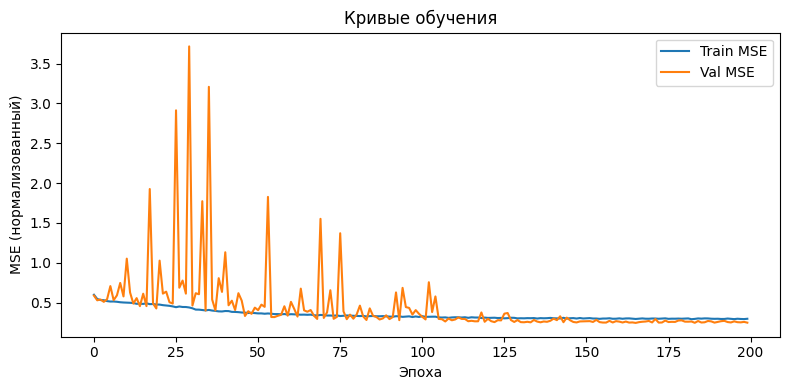

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train MSE')
plt.plot(val_losses,   label='Val MSE')
plt.xlabel('Эпоха')
plt.ylabel('MSE (нормализованный)')
plt.title('Кривые обучения')
plt.legend()
plt.tight_layout()
plt.show()


### 9. Оценка качества модели
Вычисляет метрики в исходных единицах энергии (после денормализации). Scatter-диаграмма «предсказание vs истина» визуально показывает качество: идеальная модель даёт точки строго на диагонали `y = x`.

MAE  = 26.8030
RMSE = 168.6051


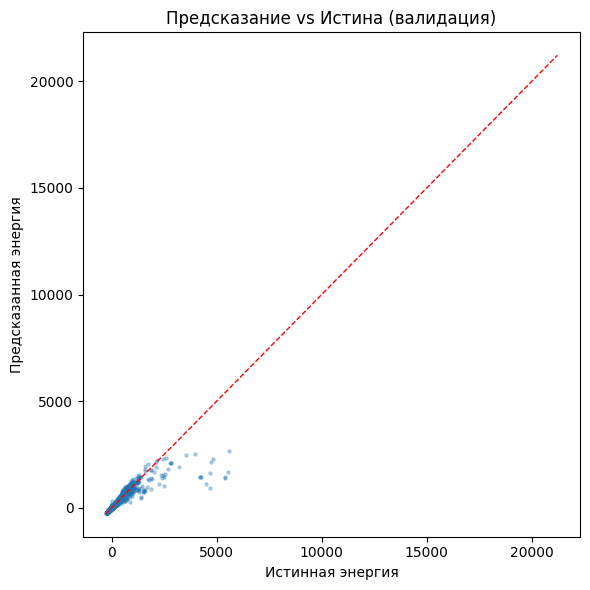

In [ ]:
model.eval()
with torch.no_grad():
    y_pred_norm = model(X_val).numpy()

y_pred = y_pred_norm * y_std + y_mean
y_true = y_val.numpy() * y_std + y_mean

mae  = np.abs(y_pred - y_true).mean()
rmse = np.sqrt(((y_pred - y_true) ** 2).mean())
print(f"MAE  = {mae:.4f}")
print(f"RMSE = {rmse:.4f}")

plt.figure(figsize=(6, 6))
sample = np.random.choice(len(y_true), size=min(5000, len(y_true)), replace=False)
plt.scatter(y_true[sample], y_pred[sample], alpha=0.3, s=5)
lims = [y_true.min(), y_true.max()]
plt.plot(lims, lims, 'r--', linewidth=1)
plt.xlabel('Истинная энергия')
plt.ylabel('Предсказанная энергия')
plt.title('Предсказание vs Истина (валидация)')
plt.tight_layout()
plt.show()


### 10. Сохранение модели
Сохраняет веса модели вместе со статистиками нормализации. 

In [ ]:
torch.save({
    "model_state_dict": model.state_dict(),
    "X_mean": X_mean, "X_std": X_std,
    "y_mean": y_mean, "y_std": y_std,
}, "neuralwinds_model.pt")
print("Модель сохранена в neuralwinds_model.pt")


Модель сохранена в neuralwinds_model.pt
